Speech Emotion Recognition (SER) using CNN

Classifies 8 emotions from speech using MFCC features + 1D CNN on the RAVDESS dataset.

Emotions: neutral, calm, happy, sad, angry, fearful, disgust, surprised

In [45]:
import os
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import joblib

from IPython.display import Audio, display

from tensorflow.keras.layers import Dense, Conv1D, Flatten, Dropout, Activation, BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler   

In [46]:
audio_file_path = "dataset/Actor_07/03-01-02-01-02-01-07.wav"

sr = 22050

display(Audio(filename=audio_file_path, rate=sr))

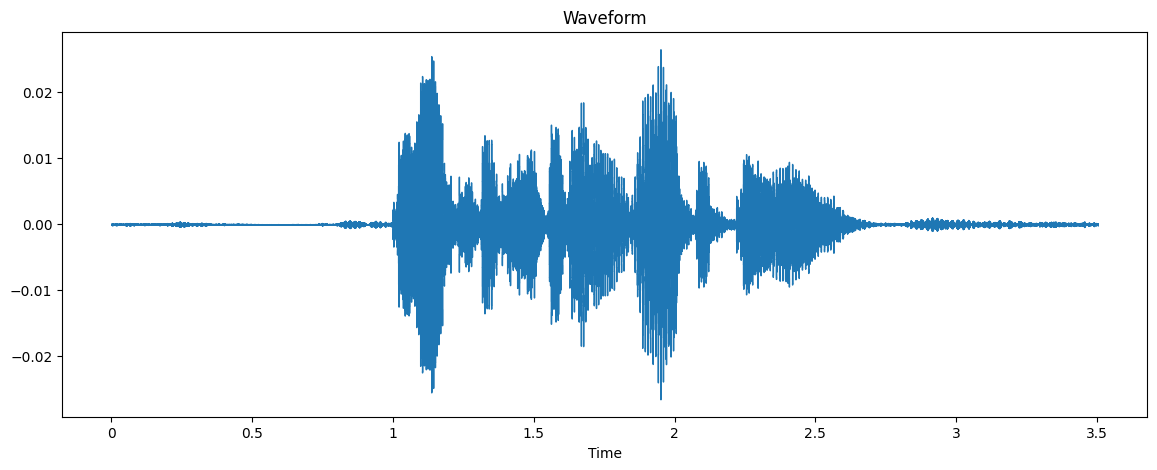

In [47]:
y, sr = librosa.load(audio_file_path, sr=sr)

plt.figure(figsize=(14,5))
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform")
plt.show()

In [48]:
def extract_mfcc(file_path, sr=22050, n_mfcc=40):
    
    y, sr = librosa.load(file_path, sr=sr, res_type="kaiser_fast")
   
    y, _ = librosa.effects.trim(y) 
    mfccs = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=n_mfcc
    )
    
    mfccs_mean = np.mean(mfccs.T, axis=0)
    
    return mfccs_mean

In [49]:
dataset_path = "F:\ML\SER\Final_SER\dataset"
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
mfcc_features = []

for root, dirs, files in os.walk(dataset_path):
    
    for file in files:
        
        if file.endswith(".wav"):
            
            try:
                
                file_path = os.path.join(root, file)
                
                mfccs = extract_mfcc(file_path)
                

                file_class = int(file.split("-")[2]) - 1
                
                mfcc_features.append((mfccs, file_class))

            except ValueError as err:
                
                print(f"Error processing file {file}: {err}")
                
                continue
            
            

<>:1: SyntaxWarning: invalid escape sequence '\M'
<>:1: SyntaxWarning: invalid escape sequence '\M'
C:\Users\hp\AppData\Local\Temp\ipykernel_22148\765208524.py:1: SyntaxWarning: invalid escape sequence '\M'
  dataset_path = "F:\ML\SER\Final_SER\dataset"


In [50]:
print(f"Extracted {len(mfcc_features)} files")


Extracted 2880 files


In [53]:
x, y = zip(*mfcc_features)

x = np.asarray(x)
y = np.asarray(y)



print(x.shape, y.shape)

(2880, 40) (2880,)


In [54]:

scaler = StandardScaler()
x = scaler.fit_transform(x)


In [55]:
SAVE_DIR_PATH = "F:\ML\SER\Final_SER"

if not os.path.isdir(SAVE_DIR_PATH):
    os.makedirs(SAVE_DIR_PATH)

joblib.dump(x, os.path.join(SAVE_DIR_PATH, "x.joblib"))
joblib.dump(y, os.path.join(SAVE_DIR_PATH, "y.joblib"))

<>:1: SyntaxWarning: invalid escape sequence '\M'
<>:1: SyntaxWarning: invalid escape sequence '\M'
C:\Users\hp\AppData\Local\Temp\ipykernel_22148\258469283.py:1: SyntaxWarning: invalid escape sequence '\M'
  SAVE_DIR_PATH = "F:\ML\SER\Final_SER"


['F:\\ML\\SER\\Final_SER\\y.joblib']

In [56]:
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.3,
    random_state=42
)

In [57]:
X_traincnn = np.expand_dims(X_train, axis=2)
X_testcnn = np.expand_dims(X_test, axis=2)

print(X_traincnn.shape, X_testcnn.shape)

(2016, 40, 1) (864, 40, 1)


In [58]:
import collections
print(collections.Counter(y))

Counter({np.int64(1): 384, np.int64(2): 384, np.int64(3): 384, np.int64(4): 384, np.int64(5): 384, np.int64(6): 384, np.int64(7): 384, np.int64(0): 192})


In [59]:

model = Sequential()

model.add(Conv1D(128, 5, padding="same", input_shape=(40,1)))
model.add(BatchNormalization())          # CHANGE 5
model.add(Activation("relu"))
model.add(Dropout(0.3))

model.add(Conv1D(256, 5, padding="same"))
model.add(BatchNormalization())
model.add(Activation("relu"))
model.add(Dropout(0.3))

model.add(Flatten())

model.add(Dense(256))
model.add(Activation("relu"))
model.add(Dropout(0.3))

model.add(Dense(128))
model.add(Activation("relu"))

model.add(Dense(8))
model.add(Activation("softmax"))

model.summary()



f:\ML\SER\myenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 40, 128)        │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 40, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 40, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 40, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 40, 256)        │       164,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 40, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 40, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 40, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 10240)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │     2,621,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │         1,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 8)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,822,024 (10.77 MB)

 Trainable params: 2,821,256 (10.76 MB)

 Non-trainable params: 768 (3.00 KB)

In [60]:

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [61]:

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)


In [62]:

history = model.fit(
    X_traincnn,
    y_train,
    epochs=70,
    batch_size=32,
    validation_data=(X_testcnn, y_test),
    callbacks=[early_stop]
)

Epoch 1/70
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - accuracy: 0.2644 - loss: 2.0707 - val_accuracy: 0.1493 - val_loss: 1.9966
Epoch 2/70
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.4241 - loss: 1.5342 - val_accuracy: 0.1528 - val_loss: 2.1795
Epoch 3/70
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.5184 - loss: 1.2931 - val_accuracy: 0.2014 - val_loss: 2.2571
Epoch 4/70
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 0.5709 - loss: 1.1350 - val_accuracy: 0.3287 - val_loss: 1.9410
Epoch 5/70
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step - accuracy: 0.6195 - loss: 1.0053 - val_accuracy: 0.3738 - val_loss: 1.9135
Epoch 6/70
63/63 ━━━━━━━━━━━━━━━━━━━━ 31s 391ms/step - accuracy: 0.6652 - loss: 0.8877 - val_accuracy: 0.4595 - val_loss: 1.4951
Epoch 7/70
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 92ms/step - accuracy: 0.7029 - loss: 0.8141 - val_accuracy: 0.7025 - val_loss: 0.8867
Epoch 8/70
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 90ms/step - accuracy: 0.7450 - loss: 0.7180 - val_accuracy: 0.7199 -

In [63]:
y_pred = model.predict(X_testcnn)

y_pred_classes = np.argmax(y_pred, axis=1)

print(confusion_matrix(y_test, y_pred_classes))

print(classification_report(y_test, y_pred_classes))

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
[[ 58   6   0   3   0   0   0   0]
 [  5 101   0   0   0   0   1   0]
 [  0   0 113   0   2   8   0   0]
 [  0   0   2  93   0   4   0   0]
 [  0   0   0   2 103   0   0   2]
 [  0   0   4   6   0 105   3   0]
 [  0   2   0   0   2   2 108   8]
 [  4   0   6   0   2   2   4 103]]
              precision    recall  f1-score   support

           0       0.87      0.87      0.87        67
           1       0.93      0.94      0.94       107
           2       0.90      0.92      0.91       123
           3       0.89      0.94      0.92        99
           4       0.94      0.96      0.95       107
           5       0.87      0.89      0.88       118
           6       0.93      0.89      0.91       122
           7       0.91      0.85      0.88       121

    accuracy                           0.91       864
   macro avg       0.91      0.91      0.91       864
weighted avg       0.91      0.91      0.91       864



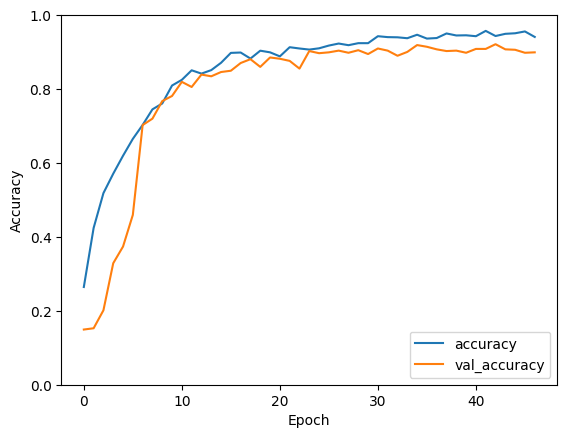

In [64]:
plt.plot(history.history["accuracy"], label="accuracy")
plt.plot(history.history["val_accuracy"], label="val_accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.ylim([0,1])

plt.legend(loc="lower right")

plt.show()

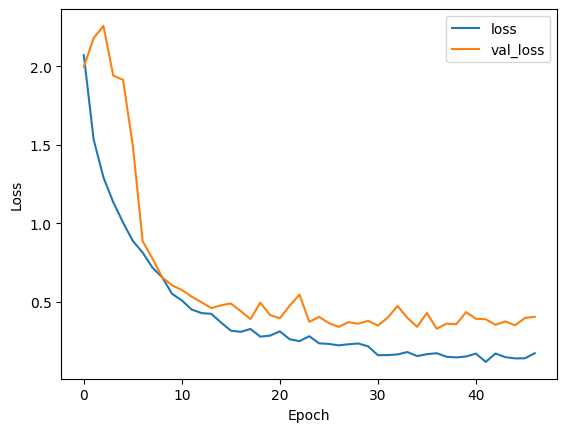

In [65]:
plt.plot(history.history["loss"], label="loss")
plt.plot(history.history["val_loss"], label="val_loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(loc="upper right")

plt.show()

In [66]:
print(x.shape)

(2880, 40)


In [67]:
emotion_labels = {
0: "neutral",
1: "calm",
2: "happy",
3: "sad",
4: "angry",
5: "fearful",
6: "disgust",
7: "surprised"
}

In [68]:
def predict_emotion(file_path):

    mfccs = extract_mfcc(file_path)

    mfccs = scaler.transform([mfccs]) 

    mfccs = np.expand_dims(mfccs, axis=2)

    prediction = model.predict(mfccs)

    predicted_class = np.argmax(prediction)

    emotion = emotion_labels[predicted_class]

    print("Predicted Emotion:", emotion)

    return emotion

##  Live Recording

In [39]:
import sounddevice as sd
from scipy.io.wavfile import write

fs = 22050
seconds = 7

print("Recording...")

audio = sd.rec(int(seconds * fs), samplerate=fs, channels=1)
sd.wait()

write("recorded_audio.wav", fs, audio)

print("Recording finished")

Recording...
Recording finished


In [ ]:
predict_emotion("recorded_audio.wav")

In [70]:
test_files = [
    "dataset/Actor_10/03-01-01-01-01-01-10.wav",
    "dataset/Actor_10/03-01-01-01-01-02-10.wav",
    "dataset/Actor_10/03-01-02-01-01-01-10.wav",
]

for f in test_files:
    predict_emotion(f)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step
Predicted Emotion: neutral
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Predicted Emotion: neutral
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Predicted Emotion: calm
